# Chord Extraction with Chordino (Class Demonstration)

This notebook demonstrates how to automatically extract chords from an audio file using a classical MIR tool called Chordino.

We will:
- Load an audio file
- Extract chord labels over time
- Convert results into a structured format
- Visualize the harmonic progression

In [ ]:
# Install required libraries (run once)
!pip install chord-extractor librosa pandas matplotlib

In [2]:
# Import utilities for dynamic path detection and Python module path updates.
import sys
from pathlib import Path


def find_repo_root(marker_dir="course_code"):
    # Search upward from the current working directory first.
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / marker_dir).is_dir():
            return p
        if p == p.parent:
            break
        p = p.parent

    # Fallback: scan common roots (e.g., Colab /content) for the marker directory.
    for base in [Path("/content"), Path.cwd().resolve()]:
        if base.exists():
            for candidate in base.rglob(marker_dir):
                if candidate.is_dir():
                    return candidate.parent

    raise RuntimeError(f"Could not locate repo root containing '{marker_dir}/'.")


# Resolve repository root and make local package imports available.
REPO_ROOT = find_repo_root("course_code")
print("REPO_ROOT =", REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))



REPO_ROOT = /Users/recepgul/Desktop/ITU/Teaching/Doktora/LEE904E/music-digital-methods


## Imports

We import standard libraries for audio processing, data handling, and visualization.

In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from chord_extractor.extractors import Chordino

Please make sure VAMP_PATH is specified pointing to the directory containing the appropriate compiled library for Chordino. This can be sourced by using the Vamp Plugin Pack installer at https://code.soundsoftware.ac.uk/projects/vamp-plugin-pack


## Load Audio File

Provide the path to your audio file. The audio will be loaded for inspection and duration calculation.

In [4]:
# Set your audio file path here
audio_path = REPO_ROOT / "data/audio/001.mp3"

# Load the audio without changing its original sample rate
y, sr = librosa.load(audio_path, sr=None)

# Measure the total duration in seconds
duration = librosa.get_duration(y=y, sr=sr)

print(f"Sample rate: {sr} Hz")
print(f"Duration: {duration:.2f} seconds")

Sample rate: 44100 Hz
Duration: 29.63 seconds


## Chord Extraction

We use Chordino to estimate chords over time. The model processes the audio and returns chord labels with timestamps.

In [5]:
# Create the chord extractor
extractor = Chordino()

# Run chord estimation on the audio file
chords = extractor.extract(audio_path)

# Quick preview of the extracted chord events
print(f"Number of chord events: {len(chords)}")
chords[:5]

Number of chord events: 17


[ChordChange(chord='N', timestamp=0.371519274),
 ChordChange(chord='Gm7', timestamp=1.021678004),
 ChordChange(chord='Ab6', timestamp=4.551111111),
 ChordChange(chord='C#7', timestamp=10.959818594),
 ChordChange(chord='Eb7/G', timestamp=12.260136054)]

## Convert to Structured Format

We convert the output into a pandas DataFrame so the results are easier to inspect, interpret, and visualize.

In [6]:
# Store each chord event with a start time and label
df = pd.DataFrame([
    {"start": c.timestamp, "chord": c.chord}
    for c in chords
])

# Add an end time using the next event, or the full duration for the last chord
df["end"] = df["start"].shift(-1).fillna(duration)

# Reorder columns for a clearer table
df = df[["start", "end", "chord"]]

df.head(10)

,start,end,chord
0,0.371519,1.021678,N
1,1.021678,4.551111,Gm7
2,4.551111,10.959819,Ab6
3,10.959819,12.260136,C#7
4,12.260136,13.467574,Eb7/G
5,13.467574,15.232290,Ab6
6,15.232290,16.532608,Abm6
7,16.532608,17.368526,Eb7/G
8,17.368526,19.319002,Ab6
9,19.319002,20.619320,Abm6


## Chord Timeline Visualization

We visualize chord labels along the time axis. Each horizontal segment shows which chord is active during that time span.

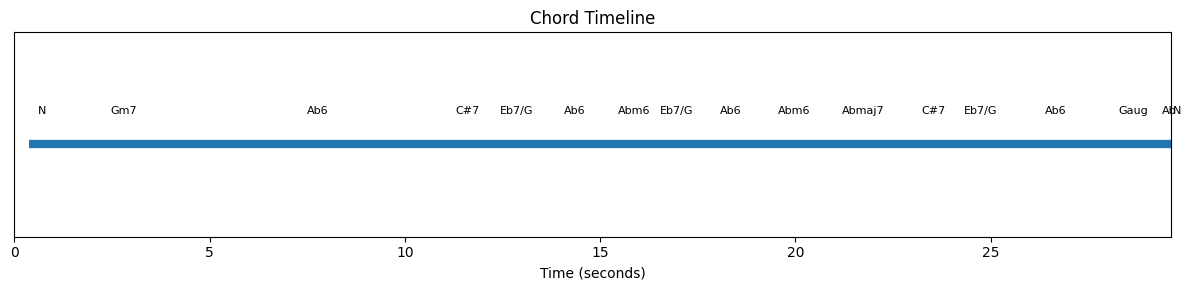

In [7]:
plt.figure(figsize=(12, 3))

# Draw one horizontal segment per chord event
for _, row in df.iterrows():
    plt.hlines(y=1, xmin=row["start"], xmax=row["end"], linewidth=6)
    midpoint = (row["start"] + row["end"]) / 2
    plt.text(midpoint, 1.03, row["chord"], ha="center", va="bottom", fontsize=8)

plt.xlim(0, duration)
plt.ylim(0.9, 1.12)
plt.yticks([])
plt.title("Chord Timeline")
plt.xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

## Audio Playback

Listen to the audio while observing the chord timeline.

In [8]:
import IPython.display as ipd

ipd.Audio(audio_path)

## Key Takeaways

- Chordino produces time-aligned chord labels from audio
- The output is symbolic chord information, not raw audio features
- This workflow is useful for harmonic analysis, segmentation, and comparison with symbolic music data